# Variant assignment compare

## Import packages

In [22]:
import os
# Typing
from typing import Tuple, Optional
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio.Phylo as bp
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import adjusted_rand_score

## Helper functions

In [100]:
def calculate_fitness_of_tips(
    tips_df: pd.DataFrame, 
    host_coordinates: Tuple[float, float],
    ag1_col: str = 'ag1', 
    ag2_col: str = 'ag2',
    s: float = 0.07, 
    homologous_immunity: float = 0.95
) -> pd.DataFrame:
      """
      Calculate fitness of tips based on infection risk against 
  host coordinates.
      
      Parameters:
      - tips_df: DataFrame with ag1, ag2 columns
      - host_coordinates: tuple of (ag1, ag2) for host immune 
  memory
      - s: smith_conversion factor
      - homologous_immunity: float between 0 and 1
      
      Returns:
      - Copy of tips_df with added 'fitness' column
      """
      # Create a copy of the dataframe
      result_df = tips_df.copy()

      # Calculate Euclidean distance from each tip to host coordinates
      distances = ((tips_df[ag1_col] - host_coordinates[0])**2 +
                    (tips_df[ag2_col] - host_coordinates[1])**2)**0.5

      # Calculate risk of infection (equivalent to fitness in thiscontext)
      risk = distances * s
      min_risk = 1.0 - homologous_immunity
      risk = np.maximum(min_risk, risk)
      risk = np.minimum(1.0, risk)

      # Add fitness column
      result_df['fitness'] = risk

      return result_df

## Load in data

In [111]:
# Define data paths
build = 'flu-simulated-150k-samples-final'

# Output paths
fig_path = "../../antigen-tex/figures/"
out_path = f"../results/{build}/"

# Antigen outputs
optimal_tips_path = f"../data/{build}/tips_variant_assignment_optimal.tsv"
many_vars_tips_path = f"../data/{build}/tips_variant_assignment_compare.tsv"
histories_path = f"../data/{build}/antigen-outputs/histories.csv"

# Variant assignment scores
results_path = f"../results/{build}/variant_assignment_scores.tsv"

In [112]:
tips_df = pd.read_csv(optimal_tips_path, sep="\t")
many_vars_tips_df = pd.read_csv(many_vars_tips_path, sep="\t")
histories_df = pd.read_csv(histories_path)
# Throw out burn in years
histories_df = histories_df[histories_df['year'] >= 10].copy()
histories_df['year'] = histories_df['year'] - 10

In [113]:
histories_df.head()

,year,deme,ag1,ag2,naive_fraction,experienced_hosts
40,0.0,north,7.150296,0.635567,0.1141,8859
41,0.0,tropics,6.549347,0.452353,0.1396,8604
42,0.0,south,8.712495,0.442429,0.0889,9111
43,0.0,total,7.491330,0.510029,0.1142,26574
44,1.0,north,7.390172,0.599102,0.1408,8592


In [114]:
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,...,highEpitopeMutationCount,country,aa_seq,variant,variant_ag,variant_phylo,variant_mds,variant_pca,variant_tsne,variant_umap
0,257eb400,-0.0362,0,1,0,1,60.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.7636,0.1655,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,4,0
1,3efb165d,-0.0360,0,1,0,0,1392.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.0705,-0.3752,...,0,north,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,4,0
2,1e0b518b,-0.0253,0,1,0,1,33.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.5491,2.7890,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,4,0
3,576c71ea,-0.0185,0,1,0,1,1589.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.0705,-0.3752,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,4,0
4,78d1ddb0,-0.0085,0,0,0,1,32.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.5491,2.7890,...,0,tropics,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,4,0


In [115]:
# Grab the total deme for histories
host_memory_df = histories_df.query("deme == 'total'")

In [116]:
variant_cols = [col for col in tips_df.columns if col.startswith('variant_')]

## Calculate variance of fitness across variant labels

In [117]:
# Now create a loop to do this for every time point
all_results = {
    'year': [],
    **{col: [] for col in variant_cols}
}
time_points = sorted(host_memory_df['year'].unique())
for t in time_points:    
    # Get host coordinates at time t
    host_coords_t = (host_memory_df.loc[host_memory_df['year'] == t, 'ag1'].values[0],
                     host_memory_df.loc[host_memory_df['year'] == t, 'ag2'].values[0])
    
    # Calculate fitness for tips at time t
    tips_with_fitness_df = calculate_fitness_of_tips(
        many_vars_tips_df,
        host_coordinates=host_coords_t
    )
    
    # Calculate variance in fitness for each variant assignment method
    results = {}
    for var_col in variant_cols:
        variances = tips_with_fitness_df.groupby(var_col)['fitness'].var()
        results[var_col] = variances.mean()

    # Store results
    all_results['year'].append(t)
    for var_col in variant_cols:
        all_results[var_col].append(results[var_col])

In [118]:
all_results_df = pd.DataFrame(all_results)
all_results_df.head()

,year,variant_ag,variant_phylo,variant_mds,variant_pca,variant_tsne,variant_umap
0,0.0,0.000120,0.000551,0.000328,0.000289,0.000333,0.000759
1,1.0,0.000122,0.000624,0.000369,0.000331,0.000380,0.000844
2,2.0,0.000138,0.000916,0.000428,0.000391,0.000460,0.001027
3,3.0,0.000134,0.000962,0.000464,0.000425,0.000488,0.001441
4,4.0,0.000159,0.001057,0.000569,0.000550,0.000551,0.001898


## Average variant variance over time

In [119]:
plt.style.use('seaborn-v0_8-paper')

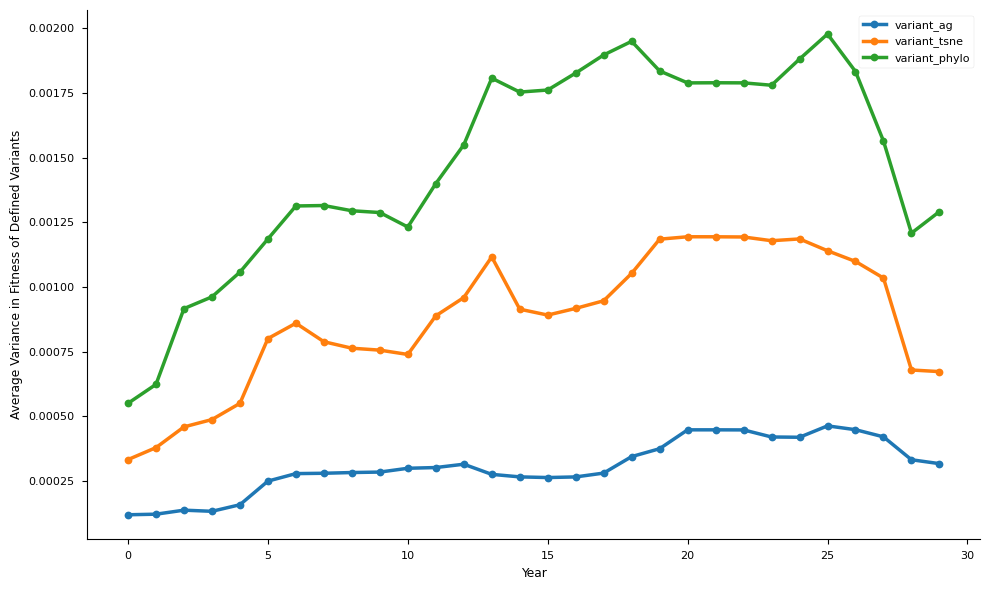

In [35]:
# Now create a lineplot to visualize the results
plt.figure(figsize=(10, 6))
for var_col in ['variant_ag', 'variant_tsne', 'variant_phylo']:
    plt.plot(all_results_df['year'], all_results_df[var_col], linewidth=2.5, marker='o', label=var_col)
plt.xlabel('Year')
plt.ylabel('Average Variance in Fitness of Defined Variants')
#plt.title('Average Variance in Fitness of Defined Variants by Variant Assignment Method Over Time')
# Remove top and right spines
sns.despine()
plt.tight_layout()
plt.legend()
plt.show()

## Bubble plot

In [29]:
def plot_variant_comparison(tips_df, method_x='ag', method_y='pca', min_count=10, figsize=(12, 10)):
    """
    Create bubble plot comparing two variant assignment methods.
    
    Parameters
    ----------
    tips_df : pd.DataFrame
        DataFrame with variant assignment columns
    method_x : str
        Method name for x-axis (e.g., 'ag', 'mds', 'pca')
    method_y : str
        Method name for y-axis (e.g., 'ag', 'mds', 'pca', 'umap', 'tsne')
    min_count : int
        Minimum count threshold for filtering combinations
    figsize : tuple
        Figure size (width, height)
    """
    
    # Calculate ARI
    ari = adjusted_rand_score(tips_df[f'variant_{method_x}'], tips_df[f'variant_{method_y}'])
    
    # Count observations for each combination
    variant_counts = tips_df.groupby([f'variant_{method_x}', f'variant_{method_y}']).size().reset_index(name='count')
    variant_counts_filtered = variant_counts[variant_counts['count'] >= min_count]
    
    # Create the bubble plot
    fig, ax = plt.subplots(figsize=figsize)
    
    scatter = ax.scatter(
        x=variant_counts_filtered[f'variant_{method_x}'],
        y=variant_counts_filtered[f'variant_{method_y}'],
        s=variant_counts_filtered['count'] * 5,
        alpha=0.6,
        edgecolors='none'
    )
    
    # Create formatter function dynamically
    def make_formatter(method_name):
        def formatter(val, pos):
            return f'{method_name}_{int(val)}'
        return formatter
    
    # Apply formatters to axes
    ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(method_x)))
    ax.yaxis.set_major_formatter(FuncFormatter(make_formatter(method_y)))
    
    # Set all y-ticks
    ax.set_yticks(range(int(variant_counts_filtered[f'variant_{method_y}'].min()), 
                        int(variant_counts_filtered[f'variant_{method_y}'].max()) + 1))
    
    ax.set_title(f'Comparison of variant assignments (ARI={ari:.3f})', fontsize=14)
    
    # Helper function for nice rounding
    def round_to_nice(value):
        if value < 10:
            return int(np.ceil(value))
        elif value < 100:
            return int(np.ceil(value / 10) * 10)
        elif value < 1000:
            return int(np.ceil(value / 50) * 50)
        else:
            return int(np.ceil(value / 100) * 100)
    
    # Get actual data range
    counts = variant_counts_filtered['count'].values
    min_count_val = counts.min()
    max_count_val = counts.max()
    
    # Get quantiles and round them nicely
    legend_counts = [
        round_to_nice(min_count_val),
        round_to_nice(np.quantile(counts, 0.33)),
        round_to_nice(np.quantile(counts, 0.66)),
        round_to_nice(max_count_val)
    ]
    
    # Remove duplicates while preserving order
    legend_counts = list(dict.fromkeys(legend_counts))
    
    # Create legend outside plot
    legend_bubbles = []
    for count in legend_counts:
        legend_bubbles.append(plt.scatter([], [], s=count*5, alpha=0.6, color='steelblue', edgecolors='none'))
    
    legend = ax.legend(legend_bubbles, legend_counts,
                       scatterpoints=1,
                       frameon=True, 
                       title='Count',
                       loc='upper left',
                       bbox_to_anchor=(1.02, 1),
                       borderpad=3.5,
                       handletextpad=2.5,
                       labelspacing=4.5)
    
    plt.tight_layout()
    plt.show()
    #return fig, ax

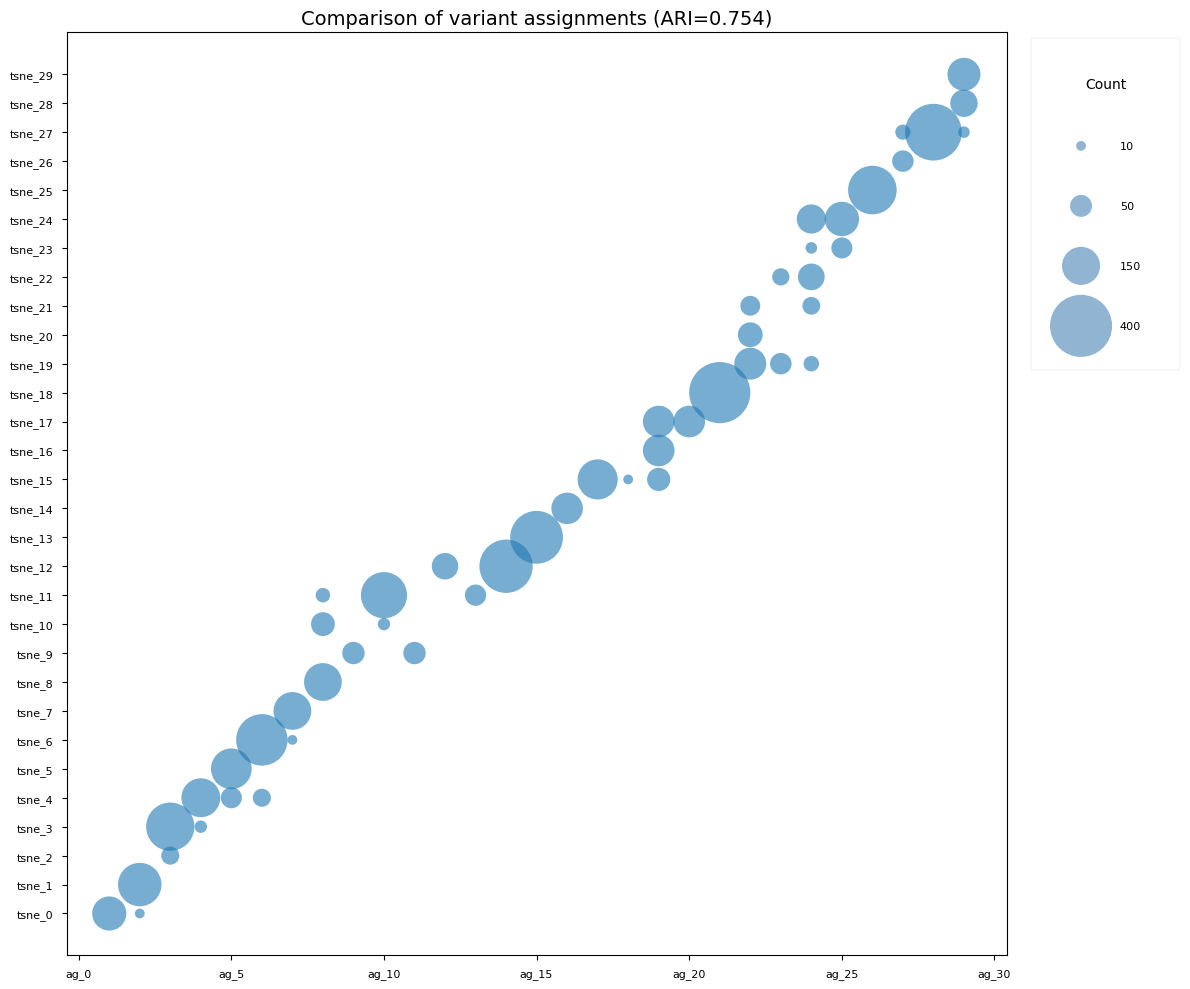

In [30]:
plot_variant_comparison(tips_df, method_x='ag', method_y='tsne')


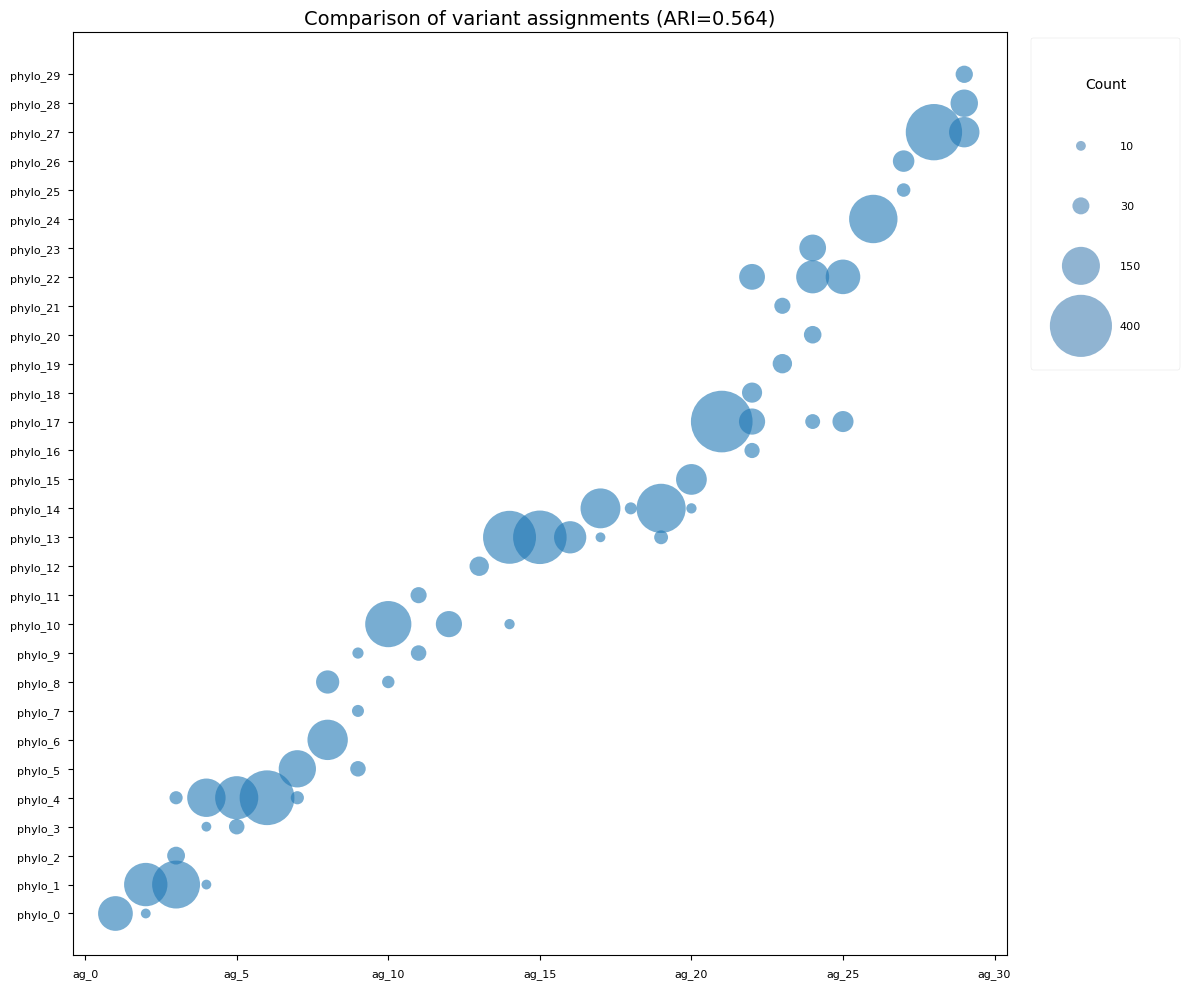

In [31]:
plot_variant_comparison(tips_df, method_x='ag', method_y='phylo')